# 181. Employees Earning More Than Their Managers
https://leetcode.com/problems/employees-earning-more-than-their-managers/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Self-Join | O(n) | O(n) | Join employee to manager |
| Correlated Subquery | O(n^2) | O(1) | Subquery per row |
| WHERE EXISTS | O(n^2) | O(1) | EXISTS check |

## Methodology

This is a SQL problem. The Employee table has id, name, salary, and managerId.
We self-join the table: join each employee with their manager row, then filter
where the employee's salary exceeds the manager's salary.

## Solutions

### C#

In [ ]:
// SQL Problem - Employees Earning More Than Their Managers
// SQL Solution:
//
// SELECT e.name AS Employee
// FROM Employee e
// JOIN Employee m ON e.managerId = m.id
// WHERE e.salary > m.salary;

// C# programmatic equivalent
using System;
using System.Linq;
using System.Collections.Generic;

public class Employee
{
    public int Id { get; set; }
    public string Name { get; set; }
    public int Salary { get; set; }
    public int? ManagerId { get; set; }
}

public class Solution
{
    public static List<string> FindEmployees(List<Employee> employees)
    {
        var dict = employees.ToDictionary(e => e.Id);
        return employees
            .Where(e => e.ManagerId.HasValue
                     && dict.ContainsKey(e.ManagerId.Value)
                     && e.Salary > dict[e.ManagerId.Value].Salary)
            .Select(e => e.Name)
            .ToList();
    }
}

// Test
var emps = new List<Employee>
{
    new Employee { Id = 1, Name = "Joe", Salary = 70000, ManagerId = 3 },
    new Employee { Id = 2, Name = "Henry", Salary = 80000, ManagerId = 4 },
    new Employee { Id = 3, Name = "Sam", Salary = 60000, ManagerId = null },
    new Employee { Id = 4, Name = "Max", Salary = 90000, ManagerId = null }
};
Console.WriteLine(string.Join(", ", Solution.FindEmployees(emps))); // Joe

### Python

In [ ]:
// SQL Problem - Python programmatic equivalent
//
// def find_employees(employees):
//     by_id = {e['id']: e for e in employees}
//     return [
//         e['name'] for e in employees
//         if e.get('managerId') and e['managerId'] in by_id
//         and e['salary'] > by_id[e['managerId']]['salary']
//     ]

### Go

In [ ]:
// SQL Problem - Go programmatic equivalent
//
// type Employee struct {
//     ID        int
//     Name      string
//     Salary    int
//     ManagerID *int
// }
//
// func findEmployees(employees []Employee) []string {
//     byID := make(map[int]Employee)
//     for _, e := range employees {
//         byID[e.ID] = e
//     }
//     var result []string
//     for _, e := range employees {
//         if e.ManagerID != nil {
//             if mgr, ok := byID[*e.ManagerID]; ok && e.Salary > mgr.Salary {
//                 result = append(result, e.Name)
//             }
//         }
//     }
//     return result
// }

### Rust

In [ ]:
// SQL Problem - Rust programmatic equivalent
//
// use std::collections::HashMap;
//
// struct Employee {
//     id: i32,
//     name: String,
//     salary: i32,
//     manager_id: Option<i32>,
// }
//
// fn find_employees(employees: &[Employee]) -> Vec<&str> {
//     let by_id: HashMap<i32, &Employee> =
//         employees.iter().map(|e| (e.id, e)).collect();
//     employees.iter()
//         .filter(|e| {
//             e.manager_id
//                 .and_then(|mid| by_id.get(&mid))
//                 .map_or(false, |mgr| e.salary > mgr.salary)
//         })
//         .map(|e| e.name.as_str())
//         .collect()
// }

## Example Scenarios

### 1. Common Case — Standard Manager Comparison

**Input:** Employee table: `{(1,'Joe',70000,3), (2,'Henry',80000,4), (3,'Sam',60000,NULL), (4,'Max',90000,NULL)}`

Joe earns \$70k and reports to Sam who earns \$60k, so Joe qualifies. Henry earns \$80k but reports to Max at \$90k, so Henry does not qualify. Self-join matches each `managerId` to the manager's row.

**WHY it's useful:** Basic self-join walkthrough. The join produces $n$ result rows (one per employee with a manager), then the `WHERE` clause filters. Time: $O(n)$ with hash join.

---

### 2. Slightly Complex — Multiple Employees Beat Same Manager

**Input:** `{(1,'Alice',95000,5), (2,'Bob',72000,5), (3,'Charlie',88000,5), (4,'Diana',65000,3), (5,'Eve',70000,NULL)}`

Alice (\$95k), Bob (\$72k), and Charlie (\$88k) all report to Eve (\$70k) and all earn more. Diana (\$65k) reports to Charlie (\$88k) and earns less. Three employees qualify from the same manager.

**WHY it's tricky:** Multiple employees share one manager — each employee-manager pair is compared independently. The join fans out from the manager side.

---

### 3. Edge Case: Time Factor — Flat Hierarchy, $n = 10^5$ Rows

**Input:** $n = 100{,}000$ employees. All point to `managerId = 1` (the CEO at \$50k). Every other employee earns \$50,001.

A correlated subquery would scan the table per row: $O(n^2) = 10^{10}$ operations. The self-join with a hash index on `id` keeps it at $O(n)$ — build the index in one pass, probe 99,999 times.

**WHY it tests time:** Flat hierarchy maximizes join fan-out. Without an index, a nested-loop join degrades to $O(n^2)$.

---

### 4. Edge Case: Space Factor — Mutual Management Pairs

**Input:** $n = 50{,}000$. Pairs manage each other: `(1, mgr=2), (2, mgr=1), (3, mgr=4), (4, mgr=3), \ldots$ Salaries alternate: \$100k, \$99,999, \$100k, \$99,999.

The hash index stores all $n$ rows. Half the employees (25,000 odd-indexed) earn more than their manager. Result set is $O(n/2)$, hash map is $O(n)$.

**WHY it tests space:** Maximum result size (half the table qualifies) plus the full hash index in memory: total auxiliary space is $O(n)$.

---

### 5. Almost-Impossible — INT_MAX Salary Boundary

**Input:** `{(1,'Alpha',2147483647,2), (2,'Beta',2147483646,NULL), (3,'Gamma',0,4), (4,'Delta',1,NULL)}`

Alpha earns $2^{31}-1$ (INT_MAX) and manages under Beta at $2^{31}-2$. The difference is just \$1. Gamma earns \$0 and reports to Delta at \$1 — does not qualify.

**WHY it's extreme:** If the comparison used subtraction (`e.salary - m.salary > 0`), values near INT_MAX could overflow in 32-bit arithmetic. Pure comparison (`e.salary > m.salary`) is safe. Always compare, never subtract for this check.

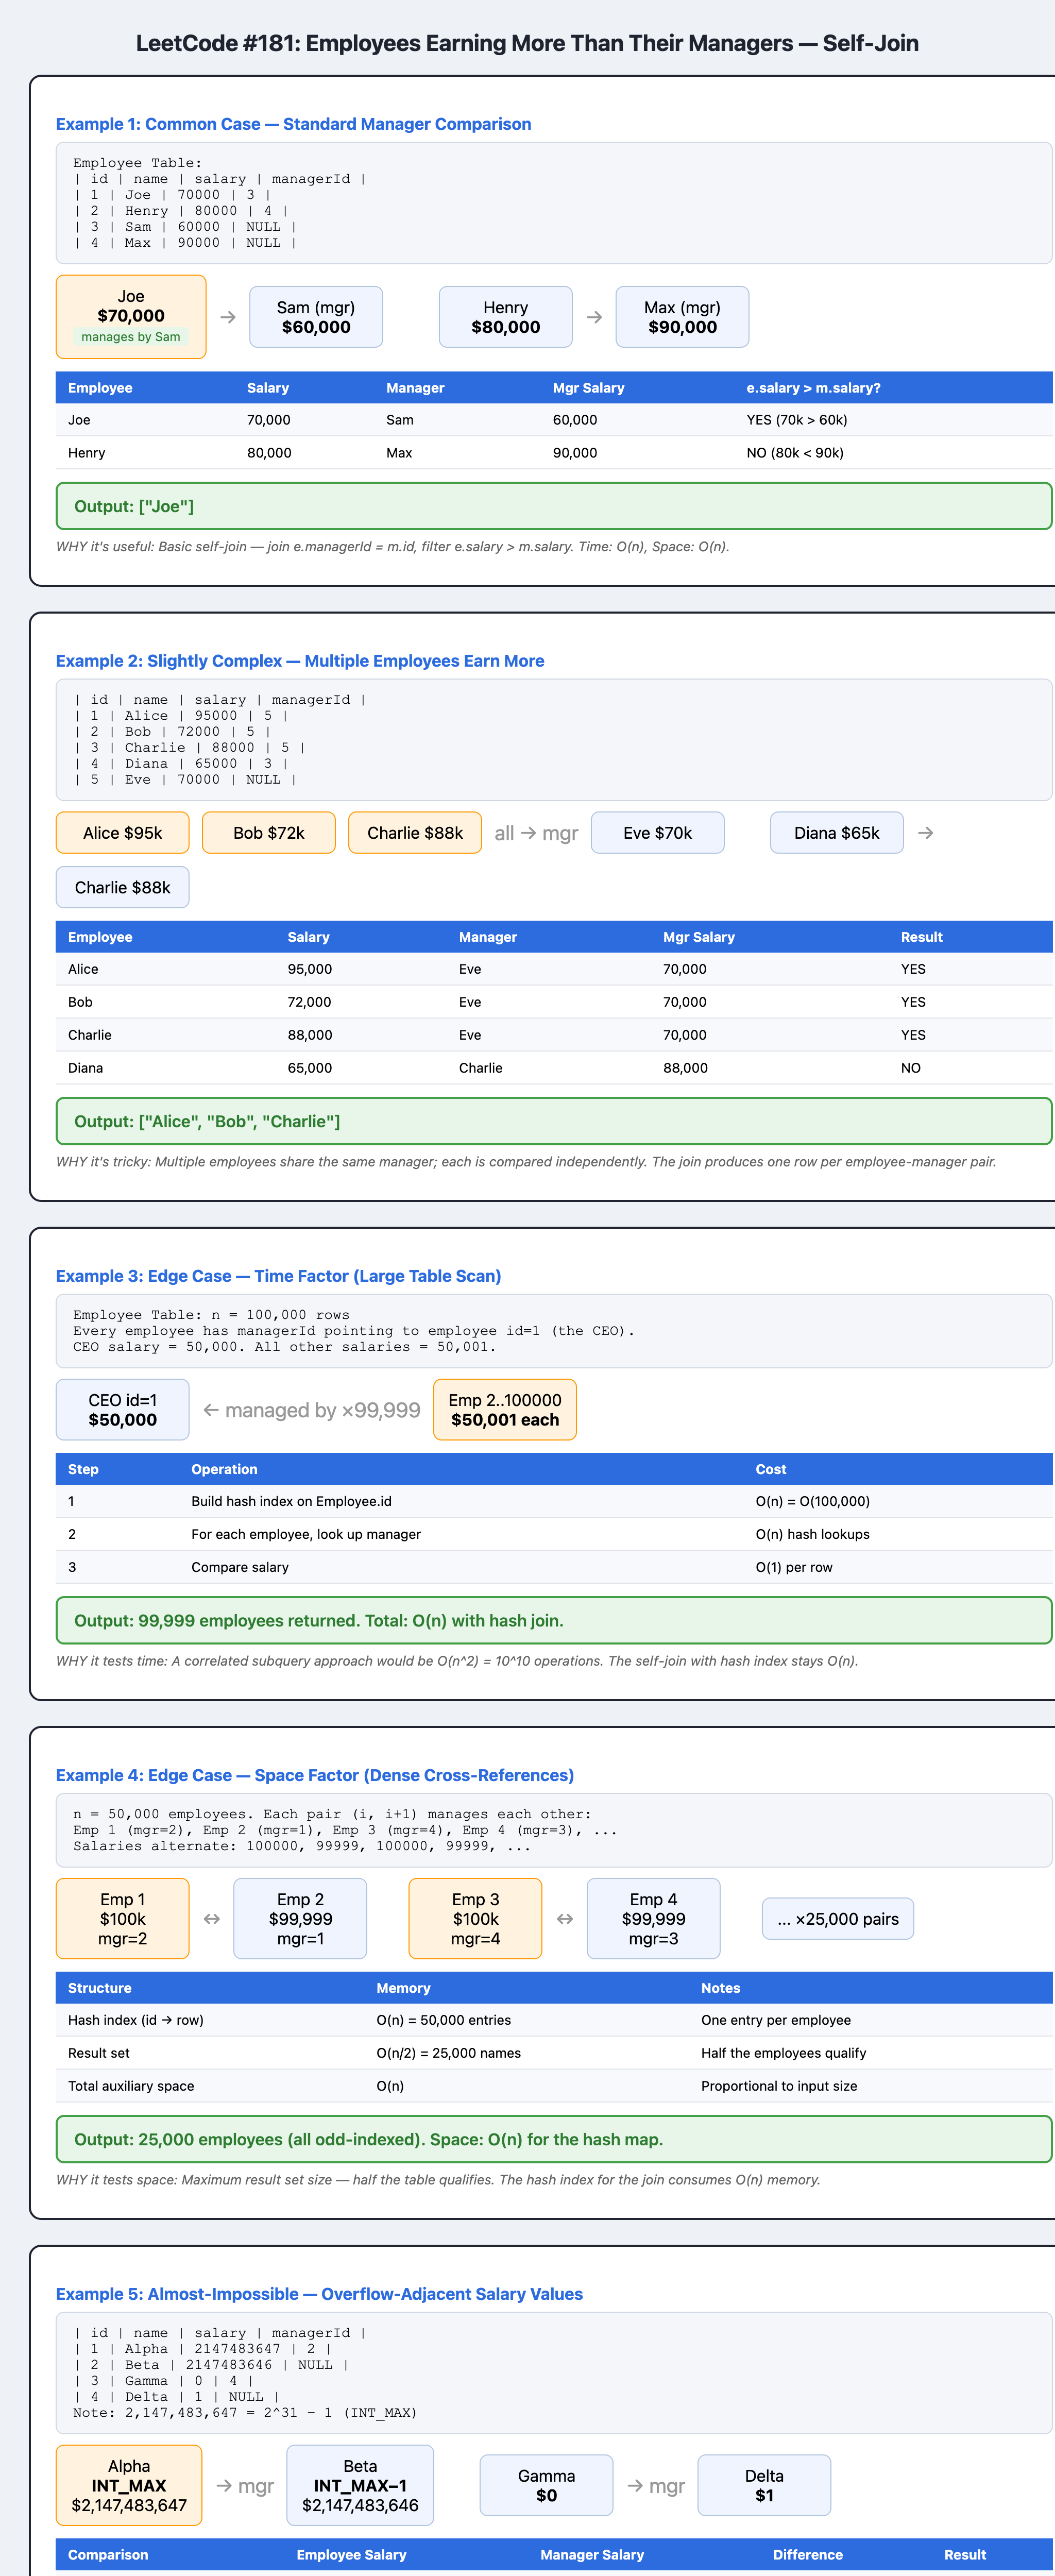